<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/11_Novelty_and_Outlier_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Novelty and Outlier Detection**

This notebook covers Novelty and Outlier Detection:

1. Introduction to Outlier and Novelty Detection
2. Understanding Isolation Forest
3. One-Class SVM for Novelty Detection
4. Detecting Outliers with Local Outlier Factor (LOF)
5. Evaluating Outlier Detection Models
6. Handling Detected Outliers
7. Choosing the Right Detection Technique

# **1. Introduction to Outlier and Novelty Detection**

Real-world ML systems encounter data that deviates from what the model was trained on. Two related but distinct phenomena require different handling strategies:

## **1.1 Outliers vs. Novelties**

| Concept | Definition | When It Appears | Example |
|---|---|---|---|
| **Outlier** | Deviates significantly from the training distribution | During training AND inference | Sensor malfunction readings in historical data |
| **Novelty** | Previously unseen pattern not present in training | Only at inference time | New fraud pattern detected post-deployment |

## **1.2 Why This Matters**

- **Model quality:** Outliers in training data can distort learned boundaries and bias predictions
- **Data poisoning:** Malicious actors intentionally inject anomalous records to corrupt model behavior
- **Production reliability:** Models encountering novelties may make dangerously confident but incorrect predictions

## **1.3 Detection Strategy Overview**

| Algorithm | Type | Supports New Predictions | Scales to Large Data |
|---|---|---|---|
| **Isolation Forest** | Outlier + Novelty | Yes | Yes |
| **One-Class SVM** | Novelty only | Yes | No |
| **Local Outlier Factor (LOF)** | Outlier only | No | No |

## **1.4 The Contamination Parameter**

Most scikit-learn detectors accept a `contamination` parameter — an estimate of the expected proportion of anomalies in the dataset. This calibrates the decision threshold for classifying points as inliers (1) or outliers (−1).

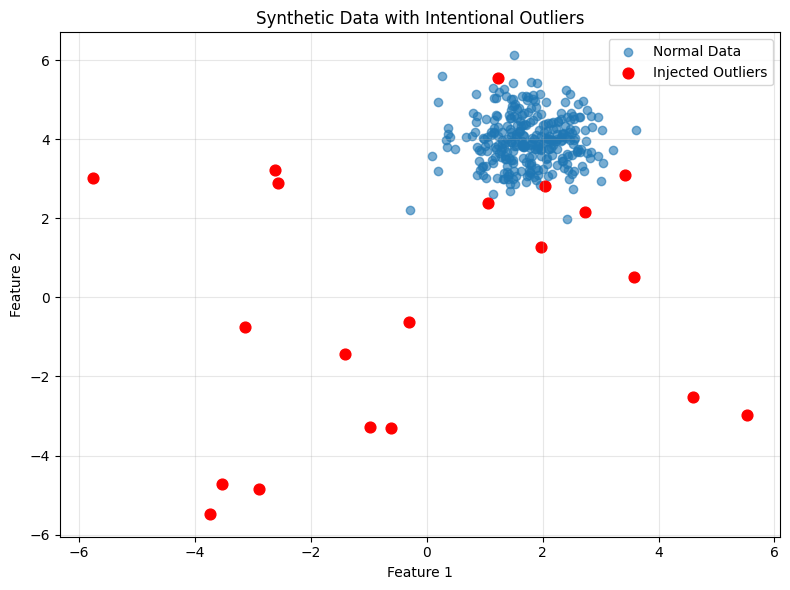

Normal samples  : 300
Outlier samples : 20
Total dataset   : 320
True contamination rate: 6.2%


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Synthetic dataset with intentional outliers
np.random.seed(2024)
X_normal, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.60, random_state=2024)
outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X_with_out = np.vstack([X_normal, outliers])

plt.figure(figsize=(8, 6))
plt.scatter(X_normal[:, 0], X_normal[:, 1], label="Normal Data", alpha=0.6)
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label="Injected Outliers", s=60)
plt.title("Synthetic Data with Intentional Outliers")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Normal samples  : {len(X_normal)}")
print(f"Outlier samples : {len(outliers)}")
print(f"Total dataset   : {len(X_with_out)}")
print(f"True contamination rate: {len(outliers)/len(X_with_out)*100:.1f}%")


# **2. Understanding Isolation Forest**

**Isolation Forest** takes a fundamentally different approach to anomaly detection: rather than profiling normal data and detecting deviations from it, it directly **isolates anomalies** using random partitioning.

## **2.1 Core Intuition**

Anomalies are "few and different" — they require **fewer random splits to isolate** than normal points. The algorithm builds an ensemble of random trees (an isolation forest) and measures the path length needed to isolate each point.

## **2.2 Algorithm Steps**

1. Randomly select a feature and a random split threshold
2. Recursively split until the point is isolated or a depth limit is reached
3. Average the **path length** across all trees — short paths indicate anomalies
4. Convert path lengths to **anomaly scores** using the `contamination` parameter

## **2.3 Advantages**

- **No distance or density computations** — scales efficiently to high-dimensional data
- Handles **both outlier and novelty detection** (supports `predict()` on new data)
- `decision_function()` provides continuous anomaly scores for ranking
- Relatively **insensitive to feature scaling**

Predicted inliers  : 304
Predicted outliers : 16


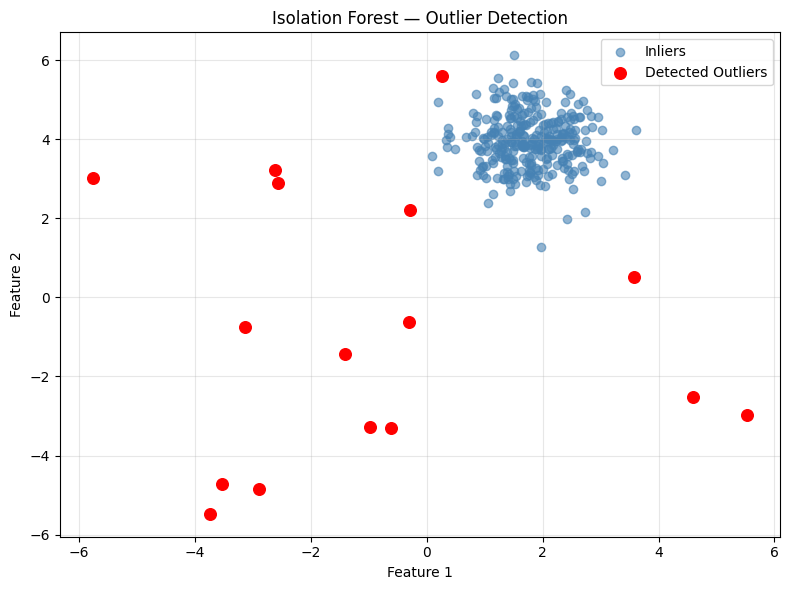

In [2]:
# Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=2024)
iso_forest.fit(X_with_out)
y_pred_iso = iso_forest.predict(X_with_out)
scores_iso  = iso_forest.decision_function(X_with_out)

inliers_iso  = X_with_out[y_pred_iso == 1]
outliers_iso = X_with_out[y_pred_iso == -1]

print(f"Predicted inliers  : {len(inliers_iso)}")
print(f"Predicted outliers : {len(outliers_iso)}")

plt.figure(figsize=(8, 6))
plt.scatter(inliers_iso[:, 0],  inliers_iso[:, 1],  color='steelblue', alpha=0.6, label='Inliers')
plt.scatter(outliers_iso[:, 0], outliers_iso[:, 1], color='red',       s=70,      label='Detected Outliers')
plt.title("Isolation Forest — Outlier Detection")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


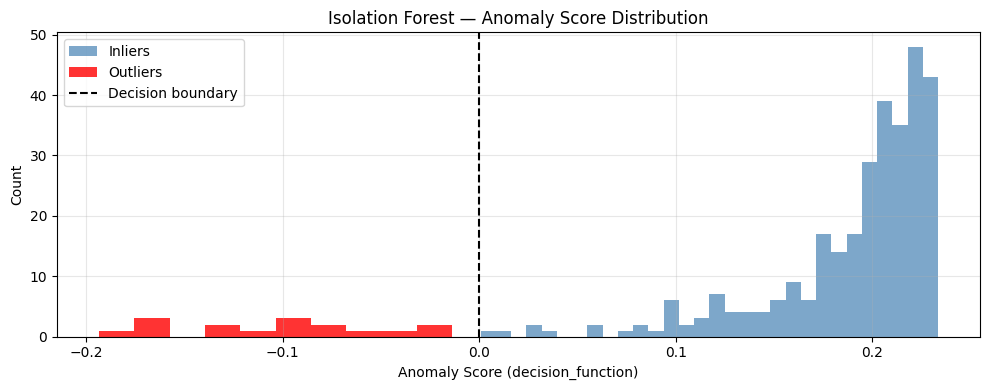

In [3]:
# Anomaly score distribution
plt.figure(figsize=(10, 4))
plt.hist(scores_iso[y_pred_iso == 1],  bins=30, alpha=0.7, color='steelblue', label='Inliers')
plt.hist(scores_iso[y_pred_iso == -1], bins=10, alpha=0.8, color='red',       label='Outliers')
plt.axvline(x=0, color='black', linestyle='--', label='Decision boundary')
plt.xlabel('Anomaly Score (decision_function)')
plt.ylabel('Count')
plt.title('Isolation Forest — Anomaly Score Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **3. One-Class SVM for Novelty Detection**

**One-Class SVM** trains exclusively on **normal data** and learns a kernel-based boundary around the normal region. Any test point falling outside this boundary is classified as a novelty.

## **3.1 Key Distinction from Outlier Detection**

- **Outlier detection:** identifies deviations within the training set
- **Novelty detection:** identifies deviations in *new, unseen* test data, having trained only on normal data

## **3.2 Key Parameters**

| Parameter | Effect |
|---|---|
| `kernel` | Defines the shape of the decision boundary (RBF is most flexible) |
| `gamma` | Controls the influence of individual training points; higher = tighter boundary |
| `nu` | Upper bound on the fraction of training errors; also a lower bound on support vectors |

## **3.3 Practical Considerations**

- Always **scale features** before fitting — One-Class SVM is sensitive to feature magnitude
- Use `decision_function()` for continuous anomaly scores
- Computationally expensive on large datasets — consider PCA for dimensionality reduction first

Test points classified as inlier  (1) : 1
Test points classified as novelty (-1): 119


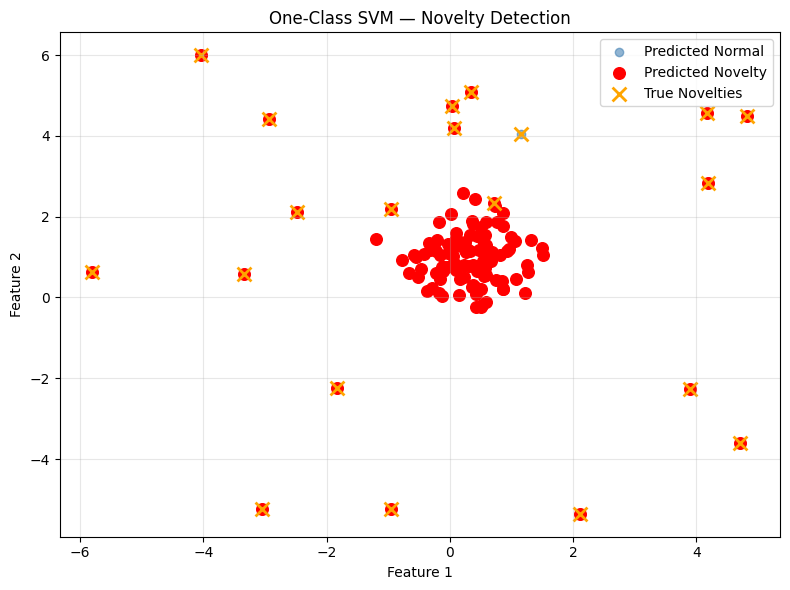

In [4]:
from sklearn.model_selection import train_test_split

# Training data: ONLY normal samples
X_train_oc, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.6, random_state=2024)

# Test data: mix of normal and novelties
X_test_normal, _ = make_blobs(n_samples=100, centers=1, cluster_std=0.6, center_box=(0,1), random_state=42)
X_test_novelty = np.random.uniform(low=-6, high=6, size=(20, 2))
X_test_oc = np.vstack([X_test_normal, X_test_novelty])

# Fit One-Class SVM on NORMAL data only
oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
oc_svm.fit(X_train_oc)
y_pred_oc = oc_svm.predict(X_test_oc)

print(f"Test points classified as inlier  (1) : {(y_pred_oc == 1).sum()}")
print(f"Test points classified as novelty (-1): {(y_pred_oc == -1).sum()}")

plt.figure(figsize=(8, 6))
plt.scatter(X_test_oc[y_pred_oc == 1, 0],  X_test_oc[y_pred_oc == 1, 1],
            color='steelblue', alpha=0.6, label='Predicted Normal')
plt.scatter(X_test_oc[y_pred_oc == -1, 0], X_test_oc[y_pred_oc == -1, 1],
            color='red', s=70, label='Predicted Novelty')
plt.scatter(X_test_novelty[:, 0], X_test_novelty[:, 1],
            color='orange', marker='x', s=100, linewidth=2, label='True Novelties')
plt.title("One-Class SVM — Novelty Detection")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **4. Detecting Outliers with LOF (Local Outlier Factor)**

**LOF** identifies outliers by comparing the **local density** of each point to that of its neighbors. Unlike global methods, LOF is sensitive to **local patterns** — it can detect anomalies in regions of varying density.

## **4.1 How LOF Works**

1. For each point $p$, compute its $k$-nearest neighbors
2. Estimate the **local reachability density** (LRD) of $p$ based on its neighbors' distances
3. Compute the **LOF score**: ratio of the average LRD of neighbors to LRD of $p$

$$\text{LOF}_k(p) = \frac{\text{avg}(\text{LRD}_k(\text{neighbor}))}{\text{LRD}_k(p)}$$

- LOF ≈ 1 → similar density to neighbors → inlier
- LOF >> 1 → much lower density than neighbors → outlier

## **4.2 Key Limitation**

LOF does **not support `predict()` on new data** — it is a purely transductive method. All data to be evaluated must be present at fit time. This makes it unsuitable for novelty detection.

## **4.3 Choosing `n_neighbors`**

- Smaller values → more sensitive to local noise
- Larger values → smoother, more robust estimates
- Typical range: 10–50

Detected inliers  : 399
Detected outliers : 21


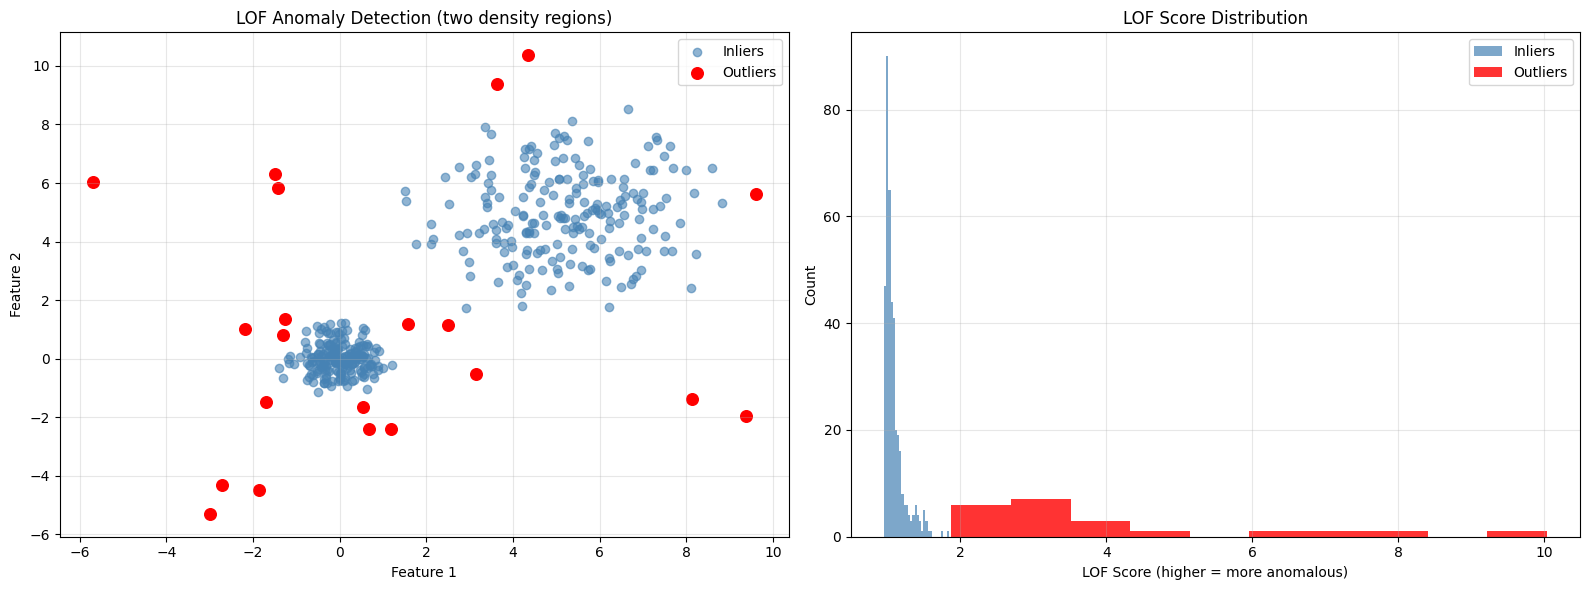

In [5]:
# LOF on clusters with different densities
X_lof1, _ = make_blobs(n_samples=400, centers=[[0,0],[5,5]], cluster_std=[0.5, 1.5], random_state=2024)
np.random.seed(2024)
outliers_lof = np.random.uniform(low=-6, high=10, size=(20, 2))
X_lof = np.vstack([X_lof1, outliers_lof])

# Fit LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_lof = lof.fit_predict(X_lof)
lof_scores = -lof.negative_outlier_factor_  # higher = more anomalous

print(f"Detected inliers  : {(y_lof == 1).sum()}")
print(f"Detected outliers : {(y_lof == -1).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Detection result
axes[0].scatter(X_lof[y_lof == 1, 0],  X_lof[y_lof == 1, 1],  color='steelblue', alpha=0.6, label='Inliers')
axes[0].scatter(X_lof[y_lof == -1, 0], X_lof[y_lof == -1, 1], color='red',       s=70,      label='Outliers')
axes[0].set_title("LOF Anomaly Detection (two density regions)")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# LOF score distribution
axes[1].hist(lof_scores[y_lof == 1],  bins=30, alpha=0.7, color='steelblue', label='Inliers')
axes[1].hist(lof_scores[y_lof == -1], bins=10, alpha=0.8, color='red',       label='Outliers')
axes[1].set_xlabel('LOF Score (higher = more anomalous)')
axes[1].set_ylabel('Count')
axes[1].set_title('LOF Score Distribution')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# **5. Evaluating Outlier Detection Models**

When ground truth labels are available (e.g., in synthetic datasets or labeled fraud datasets), standard classification metrics can be applied to evaluate anomaly detectors.

## **5.1 Label Convention**

scikit-learn anomaly detectors output:
- `1` → inlier (normal)
- `-1` → outlier/anomaly

For standard metric functions, convert to:
- `0` → inlier
- `1` → outlier

## **5.2 Metrics for Imbalanced Anomaly Data**

| Metric | Meaning for Anomaly Detection |
|---|---|
| **Precision** | Of all predicted anomalies, how many were true anomalies? |
| **Recall** | Of all true anomalies, how many were detected? |
| **F1-Score** | Balance between precision and recall |
| **ROC-AUC** | Area under ROC curve — measures ranking ability |
| **Confusion Matrix** | Full breakdown: TP, FP, TN, FN |

## **5.3 Threshold Tuning**

`decision_function()` returns continuous anomaly scores. The contamination threshold can be tuned to optimize the precision-recall trade-off for specific application requirements.

In [6]:
# Labeled evaluation
X_eval_in, _  = make_blobs(n_samples=300, centers=[[0,0]], cluster_std=0.6, random_state=2024)
X_eval_out    = np.random.uniform(low=-6, high=6, size=(30, 2))
X_eval        = np.vstack([X_eval_in, X_eval_out])
y_true_eval   = np.array([0]*300 + [1]*30)  # 0=inlier, 1=outlier

# Isolation Forest evaluation
iso_eval = IsolationForest(contamination=0.09, random_state=2024)
iso_eval.fit(X_eval)
y_pred_raw  = iso_eval.predict(X_eval)
y_pred_bin  = np.where(y_pred_raw == 1, 0, 1)  # convert: 1->0 (inlier), -1->1 (outlier)
scores_eval = iso_eval.decision_function(X_eval)

print(classification_report(y_true_eval, y_pred_bin, target_names=['Inlier','Outlier']))
print(f"ROC-AUC Score: {roc_auc_score(y_true_eval, -scores_eval):.4f}")  # negate: lower score = more anomalous


              precision    recall  f1-score   support

      Inlier       0.99      0.99      0.99       300
     Outlier       0.90      0.90      0.90        30

    accuracy                           0.98       330
   macro avg       0.95      0.95      0.95       330
weighted avg       0.98      0.98      0.98       330

ROC-AUC Score: 0.9949


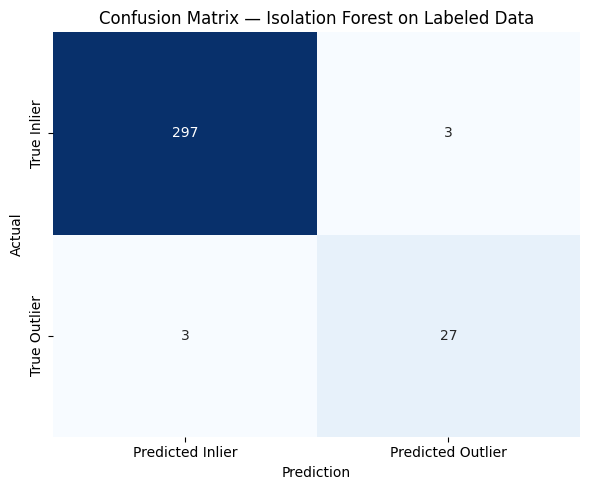

In [7]:
# Confusion matrix
cm_eval = confusion_matrix(y_true_eval, y_pred_bin)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_eval, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Inlier', 'Predicted Outlier'],
            yticklabels=['True Inlier', 'True Outlier'])
plt.title('Confusion Matrix — Isolation Forest on Labeled Data')
plt.xlabel('Prediction'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()


# **6. Handling Detected Outliers**

Detecting outliers is only half the task. Once identified, practitioners must decide what to do with them. The optimal strategy depends on domain knowledge and the nature of the anomaly.

## **6.1 Strategy Comparison**

| Strategy | Mechanism | When to Use |
|---|---|---|
| **Remove** | Drop outlier rows entirely | When outliers are measurement errors or noise |
| **Replace (Imputation)** | Replace with mean/median | When data size must be preserved |
| **Cap (Winsorization)** | Clip to quantile bounds (e.g., 5th–95th) | When extreme values are valid but disruptive |
| **Flag** | Add binary indicator feature | When outliers carry signal (e.g., fraud) |

## **6.2 Domain-First Principle**

Statistical methods identify *statistical* anomalies — not necessarily business anomalies. Always validate detected outliers with domain experts before deciding on a handling strategy.

## **6.3 Pipeline Integration**

scikit-learn's `Pipeline` can encapsulate outlier handling as a preprocessing step, ensuring consistent application to both training and test data.

In [8]:
# Outlier handling demonstration
X_han_in, _ = make_blobs(n_samples=300, centers=[[0,0]], cluster_std=0.6, random_state=2024)
X_han_out   = np.random.uniform(low=-6, high=6, size=(30, 2))
X_han       = np.vstack([X_han_in, X_han_out])

# Detect with Isolation Forest
iso_han = IsolationForest(contamination=0.09, random_state=2024)
iso_han.fit(X_han)
outlier_mask = iso_han.predict(X_han) == -1

print(f"Detected outliers: {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}%)")

# Strategy 1: Remove
X_removed = X_han[~outlier_mask]

# Strategy 2: Replace with median
X_replaced = X_han.copy()
X_replaced[outlier_mask] = np.median(X_han[~outlier_mask], axis=0)

# Strategy 3: Cap (winsorize) to 5th–95th percentile
X_df = pd.DataFrame(X_han, columns=['f1','f2'])
X_capped = X_df.copy()
for col in X_df.columns:
    lo, hi = X_df[col].quantile(0.05), X_df[col].quantile(0.95)
    X_capped[col] = X_df[col].clip(lower=lo, upper=hi)

print(f"Original size : {len(X_han)}")
print(f"After removal : {len(X_removed)}")


Detected outliers: 30 (9.1%)
Original size : 330
After removal : 300


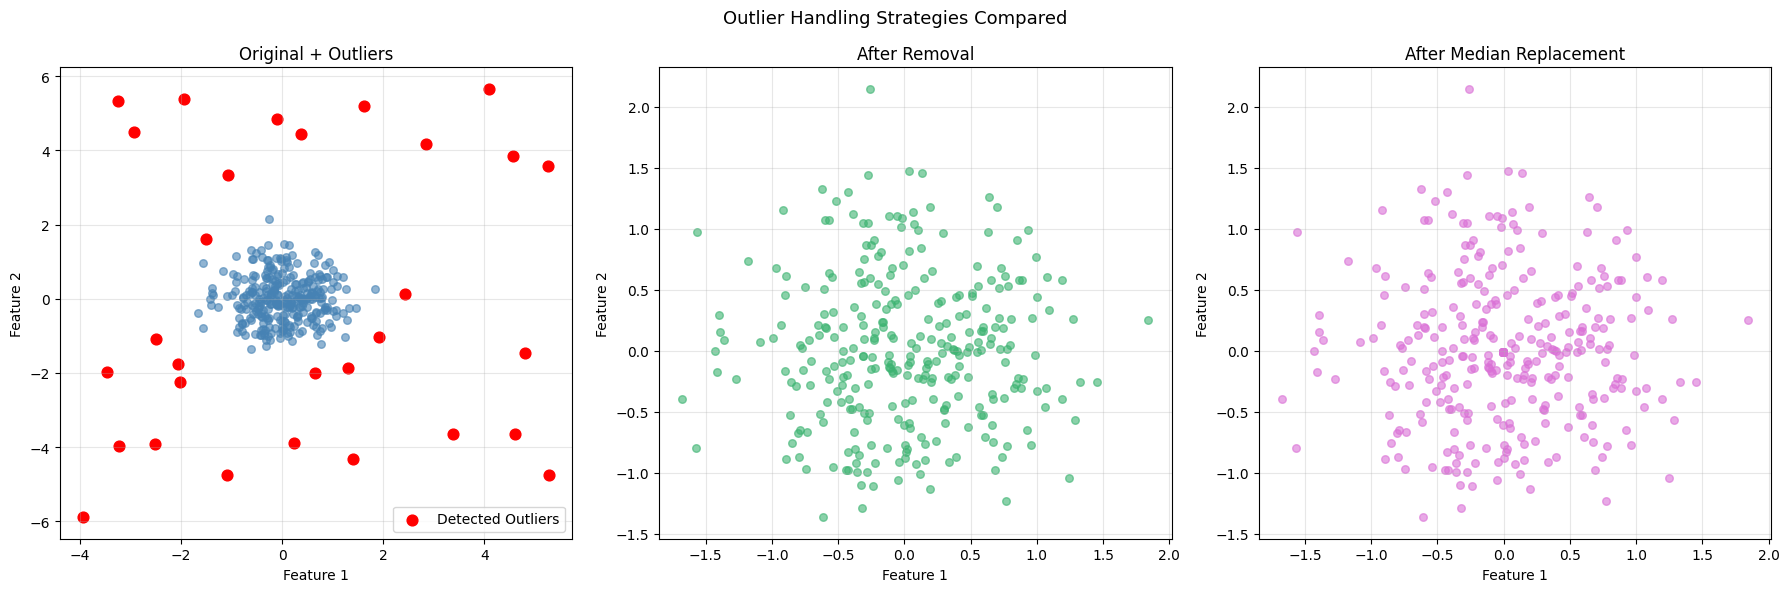

In [9]:
# Visual comparison: original vs. cleaned
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, data, title, color in zip(
    axes,
    [X_han, X_removed, X_replaced],
    ['Original + Outliers', 'After Removal', 'After Median Replacement'],
    ['steelblue', 'mediumseagreen', 'orchid']
):
    ax.scatter(data[:, 0], data[:, 1], color=color, alpha=0.6, s=30)
    if hasattr(data, '__len__') and data is X_han:
        ax.scatter(X_han[outlier_mask, 0], X_han[outlier_mask, 1],
                   color='red', s=60, label='Detected Outliers')
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
    ax.grid(True, alpha=0.3)

plt.suptitle("Outlier Handling Strategies Compared", fontsize=13)
plt.tight_layout()
plt.show()


# **7. Choosing the Right Detection Technique**

With three primary algorithms available, selection should be driven by the characteristics of the data and the operational requirements of the application.

## **7.1 Algorithm Comparison Table**

| Criterion | Isolation Forest | LOF | One-Class SVM |
|---|---|---|---|
| **Handles high dimensions** | Yes | No | Sometimes |
| **Learns from unlabeled data** | Yes | Yes | No (novelty only) |
| **Supports new predictions** | Yes | No | Yes |
| **Scales to large data** | Yes | No | No |
| **Robust to varying densities** | No | Yes | Partially |
| **Main strength** | Fast, scalable, versatile | Local anomaly detection | Kernel-based boundary modeling |

## **7.2 Decision Guide**

```
Large, high-dimensional dataset?
  → Isolation Forest

Clusters with varying densities, no need for new predictions?
  → Local Outlier Factor

Only normal training data available (novelty detection)?
  → One-Class SVM

All three available and performance is uncertain?
  → Start with Isolation Forest, iterate with LOF and One-Class SVM
  → Use ensemble voting for robustness
```

In [10]:
# Side-by-side comparison on the same dataset
X_cmp_in, _  = make_blobs(n_samples=300, centers=[[0,0]], cluster_std=0.6, random_state=2024)
X_cmp_out    = np.random.uniform(low=-6, high=6, size=(30, 2))
X_cmp        = np.vstack([X_cmp_in, X_cmp_out])
y_true_cmp   = np.array([0]*300 + [1]*30)

# Isolation Forest
iso_cmp = IsolationForest(contamination=0.09, random_state=2024)
y_iso_cmp = np.where(iso_cmp.fit_predict(X_cmp) == 1, 0, 1)

# LOF
lof_cmp = LocalOutlierFactor(n_neighbors=20, contamination=0.09)
y_lof_cmp = np.where(lof_cmp.fit_predict(X_cmp) == 1, 0, 1)

# One-Class SVM (trained only on inliers)
ocsvm_cmp = OneClassSVM(kernel='rbf', gamma='scale', nu=0.09)
ocsvm_cmp.fit(X_cmp_in)
y_ocsvm_cmp = np.where(ocsvm_cmp.predict(X_cmp) == 1, 0, 1)

# Performance summary
from sklearn.metrics import f1_score, precision_score, recall_score

results = {
    'Algorithm': ['Isolation Forest', 'LOF', 'One-Class SVM'],
    'Precision': [
        precision_score(y_true_cmp, y_iso_cmp,   zero_division=0),
        precision_score(y_true_cmp, y_lof_cmp,   zero_division=0),
        precision_score(y_true_cmp, y_ocsvm_cmp, zero_division=0),
    ],
    'Recall': [
        recall_score(y_true_cmp, y_iso_cmp),
        recall_score(y_true_cmp, y_lof_cmp),
        recall_score(y_true_cmp, y_ocsvm_cmp),
    ],
    'F1-Score': [
        f1_score(y_true_cmp, y_iso_cmp),
        f1_score(y_true_cmp, y_lof_cmp),
        f1_score(y_true_cmp, y_ocsvm_cmp),
    ],
}

summary_df = pd.DataFrame(results).set_index('Algorithm')
print("Algorithm Comparison (outlier class metrics):")
print(summary_df.round(4).to_string())


Algorithm Comparison (outlier class metrics):
                  Precision  Recall  F1-Score
Algorithm                                    
Isolation Forest     0.9333  0.9333    0.9333
LOF                  0.9333  0.9333    0.9333
One-Class SVM        0.5091  0.9333    0.6588


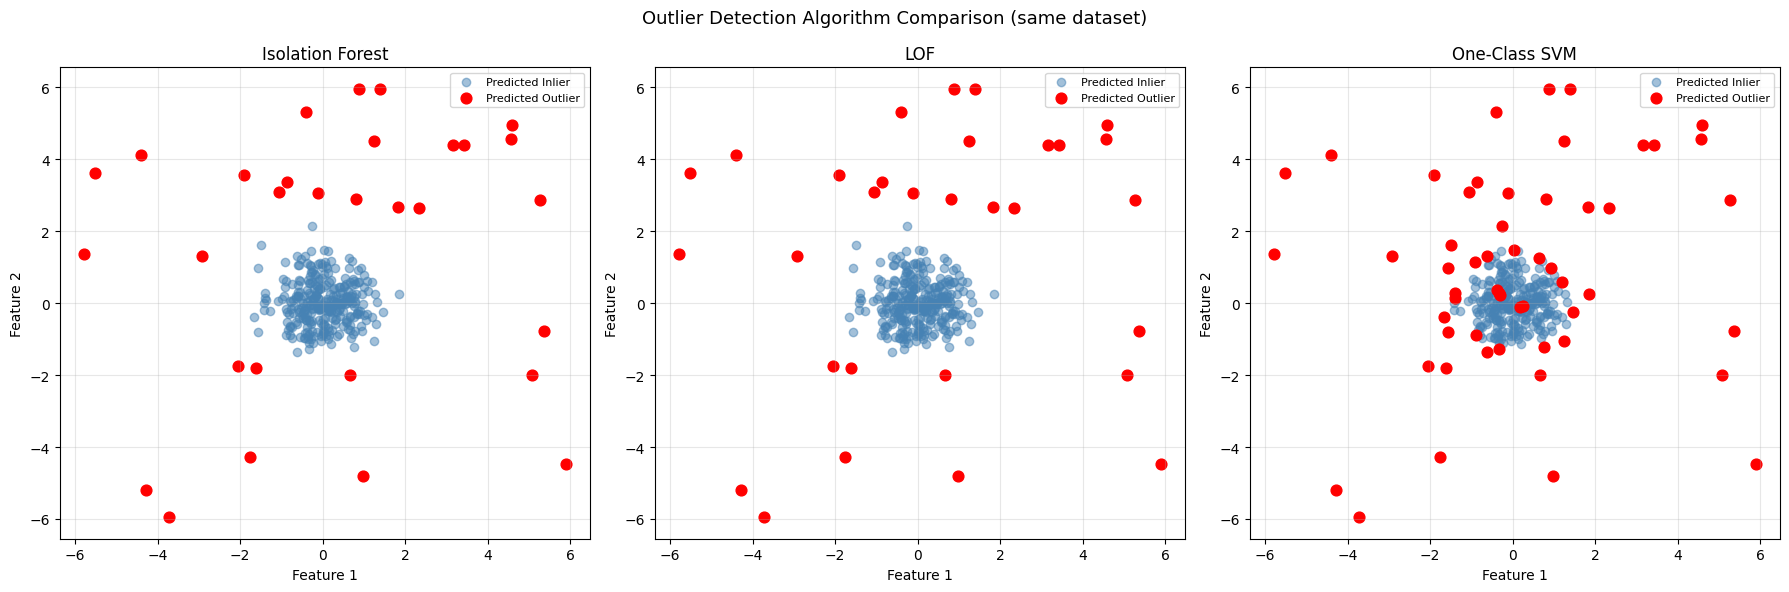

In [11]:
# Visual comparison of predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
preds = [y_iso_cmp, y_lof_cmp, y_ocsvm_cmp]
titles = ['Isolation Forest', 'LOF', 'One-Class SVM']

for ax, y_p, title in zip(axes, preds, titles):
    ax.scatter(X_cmp[y_p==0, 0], X_cmp[y_p==0, 1], color='steelblue', alpha=0.5, label='Predicted Inlier')
    ax.scatter(X_cmp[y_p==1, 0], X_cmp[y_p==1, 1], color='red',       s=60,      label='Predicted Outlier')
    ax.set_title(title)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Outlier Detection Algorithm Comparison (same dataset)", fontsize=13)
plt.tight_layout()
plt.show()
